In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

# Organized Sector Map
sectors = {
    'Banking': ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'KOTAKBANK.NS', 'AXISBANK.NS'],
    'IT': ['TCS.NS', 'INFY.NS', 'HCLTECH.NS', 'WIPRO.NS', 'LTIM.NS'],
    'Energy': ['RELIANCE.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'ADANIGREEN.NS'],
    'FMCG': ['HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS', 'VBL.NS', 'BRITANNIA.NS'],
    'Auto': ['MARUTI.NS', 'M&M.NS', 'TVSMOTOR.NS', 'BAJAJ-AUTO.NS', 'EICHERMOT.NS'],
    'Pharma': ['SUNPHARMA.NS', 'DRREDDY.NS', 'DIVISLAB.NS', 'CIPLA.NS', 'TORNTPHARM.NS']
}

# Flatten list to download all at once
all_tickers = [ticker for sublist in sectors.values() for ticker in sublist]

# Download 2 years of data
raw_data = yf.download(all_tickers, period="2y")['Close']
data = raw_data.dropna()

print(f"Successfully downloaded data for {len(data.columns)} stocks.")


[*********************100%***********************]  30 of 30 completed

Successfully downloaded data for 30 stocks.


In [30]:
import yfinance as yf
import pandas as pd
import numpy as np

# Configuration
rf = 0.0673  # Risk-Free Rate for India
sectors = {
    'Banking': ['HDFCBANK.NS', 'ICICIBANK.NS', 'SBIN.NS', 'KOTAKBANK.NS', 'AXISBANK.NS'],
    'IT': ['TCS.NS', 'INFY.NS', 'HCLTECH.NS', 'WIPRO.NS', 'LTIM.NS'],
    'Energy': ['RELIANCE.NS', 'NTPC.NS', 'ONGC.NS', 'POWERGRID.NS', 'ADANIGREEN.NS'],
    'FMCG': ['HINDUNILVR.NS', 'ITC.NS', 'NESTLEIND.NS', 'VBL.NS', 'BRITANNIA.NS'],
    'Auto': ['MARUTI.NS', 'M&M.NS', 'TVSMOTOR.NS', 'BAJAJ-AUTO.NS', 'EICHERMOT.NS'],
    'Pharma': ['SUNPHARMA.NS', 'DRREDDY.NS', 'DIVISLAB.NS', 'CIPLA.NS', 'TORNTPHARM.NS']
}

def get_sector_metrics(sector_name, ticker_list):
    # 1. Download Price Data
    df = yf.download(ticker_list, period="2y", progress=False)['Close']
    simple_rets = df.pct_change().dropna()
    log_rets = np.log(df / df.shift(1)).dropna()
    
    # 2. Performance Metrics
    ann_ret = simple_rets.mean() * 252
    ann_vol = log_rets.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    max_dd = (( (1 + simple_rets).cumprod() / (1 + simple_rets).cumprod().expanding().max() ) - 1).min()
    
    # 3. Fundamental Metrics
    fundamental_data = []
    for ticker in ticker_list:
        stock = yf.Ticker(ticker)
        info = stock.info
        
        # Robust ROE (Net Income / Shareholders Equity)
        roe = info.get('returnOnEquity')
        if not roe:
            try:
                roe = stock.income_stmt.loc['Net Income'].iloc[0] / stock.balance_sheet.loc['Common Stock Equity'].iloc[0]
            except: roe = np.nan

        fundamental_data.append({
            'Ticker': ticker,
            'P/E Ratio': info.get('trailingPE', np.nan),
            'ROE (%)': f"{roe*100:.2f}%" if not np.isnan(roe) else "N/A"
        })
    
    # 4. Combine
    fund_df = pd.DataFrame(fundamental_data).set_index('Ticker')
    perf_df = pd.DataFrame({'Return': ann_ret, 'Sharpe': sharpe, 'Max DD': max_dd})
    final = perf_df.join(fund_df)
    final['Sector'] = sector_name
    return final

# Execute for all sectors
all_sector_results = pd.concat([get_sector_metrics(s, t) for s, t in sectors.items()])

# Formatting
pd.options.display.float_format = '{:.4f}'.format
print(all_sector_results.sort_values(['Sector', 'Sharpe'], ascending=[True, False]))


               Return  Sharpe  Max DD  P/E Ratio ROE (%)   Sector
Ticker                                                           
EICHERMOT.NS   0.3859  1.3268 -0.1425    38.1657  22.23%     Auto
M&M.NS         0.3249  0.8927 -0.2242    23.2703  16.78%     Auto
TVSMOTOR.NS    0.2946  0.8654 -0.2621    81.3089  26.29%     Auto
MARUTI.NS      0.1259  0.2686 -0.2188    28.6868  15.07%     Auto
BAJAJ-AUTO.NS  0.0958  0.1126 -0.4231    29.8510  20.82%     Auto
SBIN.NS        0.2327  0.6691 -0.2394    12.0767  15.93%  Banking
ICICIBANK.NS   0.1230  0.2980 -0.1346    17.8198  16.80%  Banking
HDFCBANK.NS    0.1197  0.2895 -0.1700    18.9913  14.02%  Banking
AXISBANK.NS    0.1150  0.2055 -0.2803    15.5585  13.63%  Banking
KOTAKBANK.NS   0.0911  0.1021 -0.1607    20.7147  14.05%  Banking
NTPC.NS        0.1019  0.1287 -0.3230    20.9025  12.72%   Energy
POWERGRID.NS   0.0917  0.0910 -0.2956    19.1341  16.75%   Energy
ONGC.NS        0.0914  0.0782 -0.3226     8.9025  10.55%   Energy
RELIANCE.N

In [36]:
import pandas as pd
import numpy as np

def select_best_by_weighted_score(df, w_return=0.3, w_sharpe=0.5, w_roe=0.2):
    """
    Selects top stock per sector by forcing numeric conversion and 
    using standard Python syntax for broad compatibility.
    """
    df_copy = df.copy()

    # 1. FORCE NUMERIC: Clean and convert columns to float
    # This fixes the 'str - str' TypeError from your previous run
    target_cols = ['Return', 'Sharpe', 'ROE (%)']
    
    for col in target_cols:
        # Convert to string to clean, then to numeric
        df_copy[col] = pd.to_numeric(
            df_copy[col].astype(str).str.replace('%', '', regex=False).replace('N/A', np.nan), 
            errors='coerce'
        )

    # 2. DROP MISSING: Remove rows where data couldn't be converted
    df_clean = df_copy.dropna(subset=target_cols).copy()

    # 3. NORMALIZATION: Scale metrics 0 to 1
    for col in target_cols:
        col_min = df_clean[col].min()
        col_max = df_clean[col].max()
        
        # Avoid division by zero
        if col_max != col_min:
            df_clean['norm_' + col] = (df_clean[col] - col_min) / (col_max - col_min)
        else:
            df_clean['norm_' + col] = 0.0

    # 4. CALCULATE SCORE: Apply weights
    df_clean['Score'] = (
        (df_clean['norm_Return'] * w_return) + 
        (df_clean['norm_Sharpe'] * w_sharpe) + 
        (df_clean['norm_ROE (%)'] * w_roe)
    )

    # 5. SELECT WINNERS: Group by Sector and pick the top Score
    best_picks = df_clean.sort_values('Score', ascending=False).groupby('Sector').head(1)
    
    # Return formatted table
    return best_picks[['Sector', 'Return', 'Sharpe', 'ROE (%)', 'Score']].sort_values('Score', ascending=False)

# Execution
top_investments = select_best_by_weighted_score(all_sector_results)

print("--- Multi-Criteria Sector Winners (Final Fix) ---")
print(top_investments)


--- Multi-Criteria Sector Winners (Final Fix) ---
                Sector  Return  Sharpe  ROE (%)  Score
Ticker                                                
EICHERMOT.NS      Auto  0.3859  1.3268  22.2300 0.8390
TORNTPHARM.NS   Pharma  0.2888  0.9941  25.1800 0.7391
SBIN.NS        Banking  0.2327  0.6691  15.9300 0.6248
BRITANNIA.NS      FMCG  0.1311  0.3127  50.0200 0.6051
NTPC.NS         Energy  0.1019  0.1287  12.7200 0.4522
INFY.NS             IT -0.0397 -0.4362  32.6800 0.3346


[*********************100%***********************]  6 of 6 completed


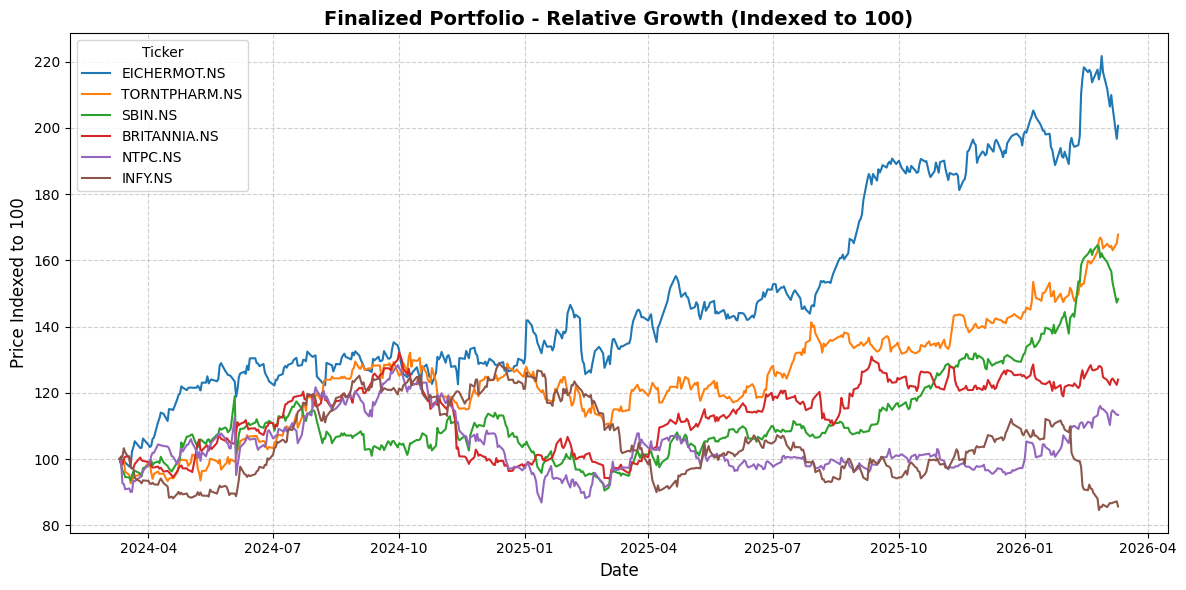

In [37]:
import yfinance as yf
import matplotlib.pyplot as plt

# Finalized list based on your weighted selection
final_tickers = [
    'EICHERMOT.NS', 'TORNTPHARM.NS', 'SBIN.NS', 
    'BRITANNIA.NS', 'NTPC.NS', 'INFY.NS'
]

# 1. Download 2 years of data
print("Downloading price data for final selection...")
data = yf.download(final_tickers, period="2y")['Close']

# 2. Normalize the data to 100
# Formula: (Current Price / Starting Price) * 100
relative_growth = (data / data.iloc[0]) * 100

# 3. Plotting
plt.figure(figsize=(12, 6))
for ticker in final_tickers:
    plt.plot(relative_growth.index, relative_growth[ticker], label=ticker, linewidth=1.5)

# Formatting to match your reference image
plt.title('Finalized Portfolio - Relative Growth (Indexed to 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price Indexed to 100', fontsize=12)
plt.legend(title='Ticker', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()


Simulation Complete: 5000 Portfolios Analyzed.

--- Maximum Sharpe Ratio Portfolio ---
Annualized Return: 27.38%
Annualized Volatility: 15.97%
Sharpe Ratio: 1.2931

Optimal Weights Allocation:
        Stock  Weight
 EICHERMOT.NS  0.1342
TORNTPHARM.NS  0.4453
      SBIN.NS  0.0125
 BRITANNIA.NS  0.0246
      NTPC.NS  0.0228
      INFY.NS  0.3607


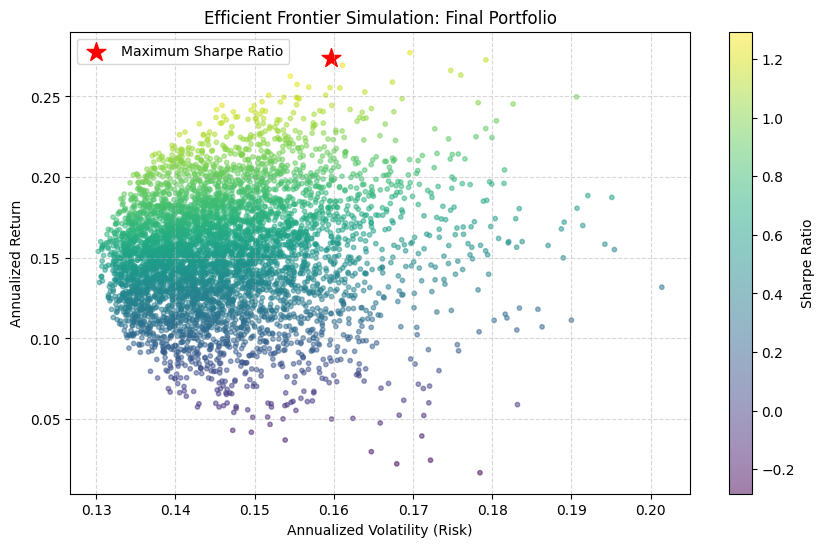

In [38]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Your finalized stock selection
final_tickers = [
    'EICHERMOT.NS', 'TORNTPHARM.NS', 'SBIN.NS', 
    'BRITANNIA.NS', 'NTPC.NS', 'INFY.NS'
]

# 1. Download and Process Data
data = yf.download(final_tickers, period="2y", progress=False)['Close']
log_returns = np.log(data / data.shift(1)).dropna()

# 2. Simulation Configuration
num_portfolios = 5000
num_assets = len(final_tickers)
risk_free_rate = 0.0673  # Updated to March 2026 G-Sec yield

# Arrays to store results
results = np.zeros((3, num_portfolios))
weights_record = []

# 3. Perform Simulation
for i in range(num_portfolios):
    # Create random weights and normalize to 1.0
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)
    
    # Calculate Annualized Portfolio Return
    p_return = np.sum(log_returns.mean() * weights) * 252
    
    # Calculate Annualized Portfolio Risk (Volatility)
    # Formula: sqrt(Weights^T * Covariance_Matrix * Weights)
    p_std = np.sqrt(np.dot(weights.T, np.dot(log_returns.cov() * 252, weights)))
    
    # Store results (Return, Volatility, Sharpe Ratio)
    results[0,i] = p_return
    results[1,i] = p_std
    results[2,i] = (p_return - risk_free_rate) / p_std

# 4. Identify Optimal Portfolios
max_sharpe_idx = np.argmax(results[2])
sdp, rp = results[1, max_sharpe_idx], results[0, max_sharpe_idx]
optimal_weights = weights_record[max_sharpe_idx]

print(f"Simulation Complete: {num_portfolios} Portfolios Analyzed.")
print(f"\n--- Maximum Sharpe Ratio Portfolio ---")
print(f"Annualized Return: {rp:.2%}")
print(f"Annualized Volatility: {sdp:.2%}")
print(f"Sharpe Ratio: {results[2, max_sharpe_idx]:.4f}")

# Display weights for the best portfolio
weight_df = pd.DataFrame({'Stock': final_tickers, 'Weight': optimal_weights})
print("\nOptimal Weights Allocation:")
print(weight_df.to_string(index=False))

# 5. Visualization (Efficient Frontier)
plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(sdp, rp, marker='*', color='red', s=200, label='Maximum Sharpe Ratio')
plt.title('Efficient Frontier Simulation: Final Portfolio')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [43]:
# Assuming 'log_returns' and 'optimal_weights' are from your previous code
var_results = calculate_portfolio_var(log_returns, optimal_weights)

print("--- Portfolio Risk Metrics (Value at Risk) ---")

# Specific formatted output for each confidence level
v95 = var_results['VaR 95%']
v99 = var_results['VaR 99%']

print(f"95% Daily Value at Risk (VaR): {v95:.2%}")
print(f"Meaning: On a ₹1,00,000 investment, you shouldn't lose more than ₹{v95 * 100000:,.0f} in a single day (95% of the time).")

print(f"\n99% Daily Value at Risk (VaR): {v99:.2%}")
print(f"Meaning: On a ₹1,00,000 investment, in a worst-case scenario (1% probability), you could lose ₹{v99 * 100000:,.0f} or more in a single day.")


--- Portfolio Risk Metrics (Value at Risk) ---
95% Daily Value at Risk (VaR): 1.59%
Meaning: On a ₹1,00,000 investment, you shouldn't lose more than ₹1,595 in a single day (95% of the time).

99% Daily Value at Risk (VaR): 2.11%
Meaning: On a ₹1,00,000 investment, in a worst-case scenario (1% probability), you could lose ₹2,113 or more in a single day.


In [45]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Define your final selection and the Benchmark (Nifty 50)
final_tickers = ['EICHERMOT.NS', 'TORNTPHARM.NS', 'SBIN.NS', 'BRITANNIA.NS', 'NTPC.NS', 'INFY.NS']
benchmark = '^NSEI'

# 2. Download 2 years of data for both
all_data = yf.download(final_tickers + [benchmark], period="2y", progress=False)['Close']
returns = all_data.pct_change().dropna()

# 3. Calculate Beta for each stock
beta_list = []
market_var = returns[benchmark].var()

for ticker in final_tickers:
    # Covariance between Stock and Market
    covariance = returns[ticker].cov(returns[benchmark])
    beta = covariance / market_var
    
    # Classification
    status = "Aggressive" if beta > 1 else "Defensive"
    
    beta_list.append({
        'Ticker': ticker,
        'Beta': round(beta, 2),
        'Type': status
    })

# 4. Display results
beta_df = pd.DataFrame(beta_list).set_index('Ticker')
print("--- Stock Beta (Market Sensitivity) ---")
print(beta_df)

# Calculate Portfolio Beta (Weighted average based on your optimal_weights)
portfolio_beta = np.dot(beta_df['Beta'], optimal_weights)
print(f"\nOverall Portfolio Beta: {portfolio_beta:.2f}")


--- Stock Beta (Market Sensitivity) ---
                Beta        Type
Ticker                          
EICHERMOT.NS  0.9600   Defensive
TORNTPHARM.NS 0.5300   Defensive
SBIN.NS       1.2200  Aggressive
BRITANNIA.NS  0.3600   Defensive
NTPC.NS       1.3000  Aggressive
INFY.NS       0.8700   Defensive

Overall Portfolio Beta: 0.73


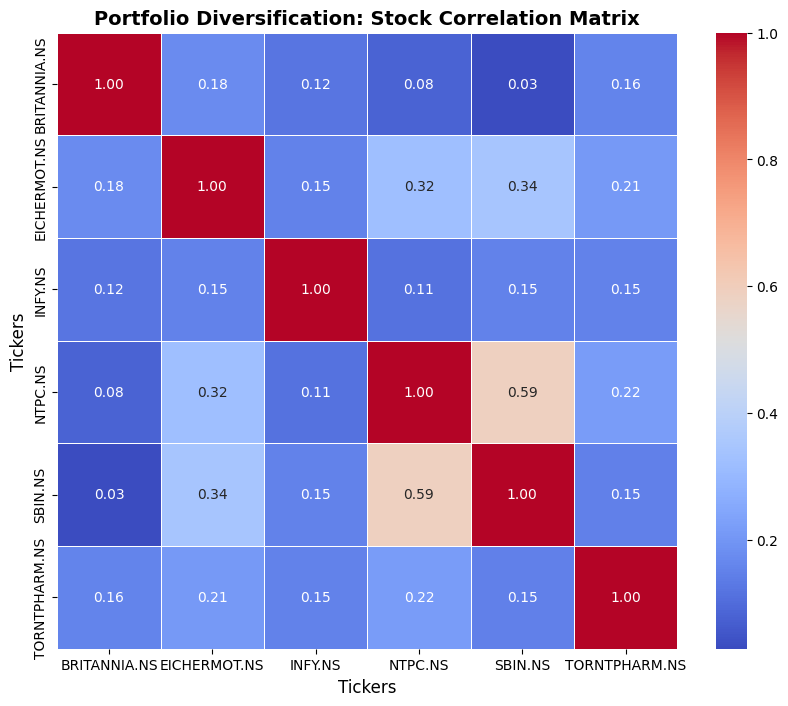

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Correlation Matrix from your log_returns (Page 5 of your PDF)
# Using 'log_returns' from your previous code block
correlation_matrix = log_returns.corr()

# 2. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Formatting
plt.title('Portfolio Diversification: Stock Correlation Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Tickers', fontsize=12)
plt.ylabel('Tickers', fontsize=12)

# Show the plot
plt.show()


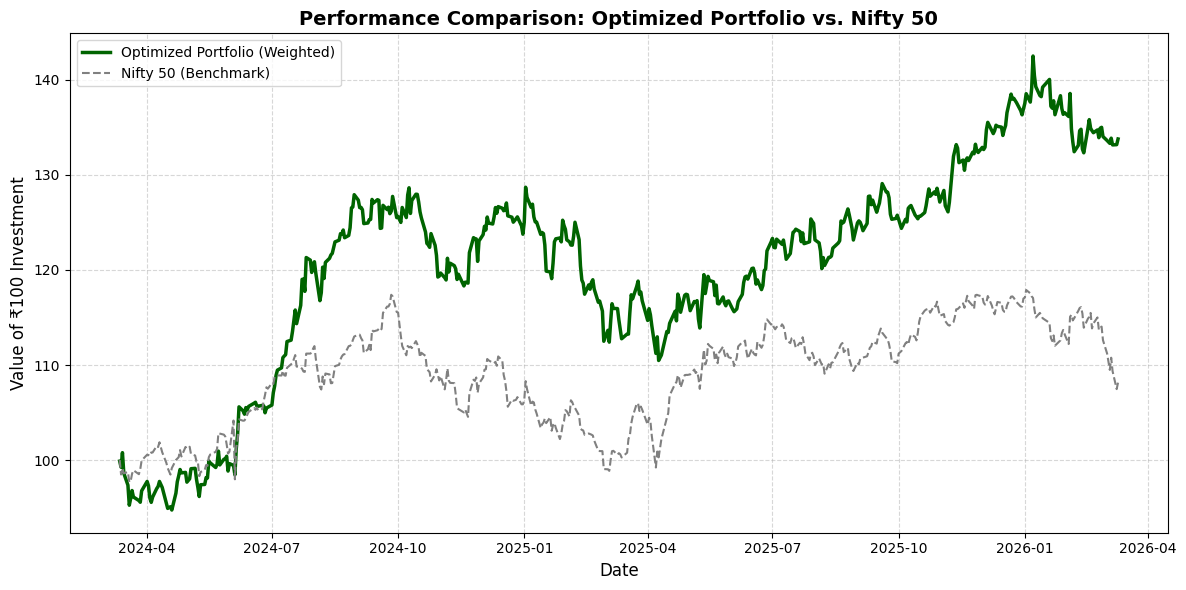

--- Strategy Performance Summary ---
Portfolio Total Return: 33.77%
Nifty 50 Total Return: 8.17%
Net Outperformance (Alpha): 25.59%


In [47]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Define final tickers and the benchmark (Nifty 50)
final_tickers = ['EICHERMOT.NS', 'TORNTPHARM.NS', 'SBIN.NS', 'BRITANNIA.NS', 'NTPC.NS', 'INFY.NS']
benchmark = '^NSEI'

# 2. Download 2 years of data
all_data = yf.download(final_tickers + [benchmark], period="2y", progress=False)['Close']
daily_returns = all_data.pct_change().dropna()

# 3. Calculate Portfolio Daily Returns using your 'optimal_weights' (from p. 6)
# Multiply each stock's daily return by its weight and sum them up
portfolio_daily_rets = (daily_returns[final_tickers] * optimal_weights).sum(axis=1)

# 4. Calculate Cumulative Returns (Starting from 1.0 or 100)
portfolio_cumulative = (1 + portfolio_daily_rets).cumprod() * 100
benchmark_cumulative = (1 + daily_returns[benchmark]).cumprod() * 100

# 5. Plotting the Comparison
plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label='Optimized Portfolio (Weighted)', linewidth=2.5, color='darkgreen')
plt.plot(benchmark_cumulative.index, benchmark_cumulative, label='Nifty 50 (Benchmark)', linewidth=1.5, linestyle='--', color='gray')

# Formatting
plt.title('Performance Comparison: Optimized Portfolio vs. Nifty 50', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value of ₹100 Investment', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Show the plot
plt.show()

# 6. Calculate Final Outperformance (Alpha)
total_port_ret = portfolio_cumulative.iloc[-1] - 100
total_bench_ret = benchmark_cumulative.iloc[-1] - 100
alpha = total_port_ret - total_bench_ret

print(f"--- Strategy Performance Summary ---")
print(f"Portfolio Total Return: {total_port_ret:.2f}%")
print(f"Nifty 50 Total Return: {total_bench_ret:.2f}%")
print(f"Net Outperformance (Alpha): {alpha:.2f}%")


In [49]:
import pandas as pd

# 1. Consolidate results from previous steps (Pages 6, 7, 8, and 10)
# These variables should already be in your environment from previous cells
summary_data = {
    'Portfolio Performance Metric': [
        'Annualized Portfolio Return', 
        'Annualized Portfolio Volatility (Risk)', 
        'Portfolio Sharpe Ratio (Efficiency)', 
        'Portfolio Beta (Market Sensitivity)',
        '95% Daily Value at Risk (VaR)',
        '99% Daily Value at Risk (VaR)',
        'Total Strategy Alpha (vs. Nifty 50)'
    ],
    'Value': [
        f"{rp:.2%}",                                # From Monte Carlo (p. 6)
        f"{sdp:.2%}",                               # From Monte Carlo (p. 6)
        f"{results[2, max_sharpe_idx]:.4f}",        # From Monte Carlo (p. 6)
        f"{portfolio_beta:.2f}",                    # From Beta Calculation (p. 8)
        f"{v95:.2%}",                               # From VaR Calculation (p. 7)
        f"{v99:.2%}",                               # From VaR Calculation (p. 7)
        f"{alpha:.2f}%"                             # From Performance Comparison (p. 10)
    ],
    'Analysis Note': [
        'Historical annualized growth rate',
        'Annualized standard deviation',
        'Risk-adjusted return (Efficiency)',
        'Sensitivity relative to Nifty 50',
        'Maximum daily loss (95% confidence)',
        'Worst-case daily loss (1% probability)',
        'Excess return generated over benchmark'
    ]
}

# 2. Create the Summary DataFrame
summary_df = pd.DataFrame(summary_data)

# 3. Print the Final Table
print("="*75)
print("   --- EXECUTIVE SUMMARY: OPTIMIZED SECTOR PORTFOLIO (2024-2026) ---   ")
print("="*75)
print(summary_df.to_string(index=False))
print("="*75)

# 4. Display Final Allocation Summary
print("\n--- FINAL RECOMMENDED ALLOCATION ---")
final_weights_df = pd.DataFrame({
    'Stock': final_tickers, 
    'Weight (%)': (optimal_weights * 100).round(2)
})
print(final_weights_df.sort_values(by='Weight (%)', ascending=False).to_string(index=False))


   --- EXECUTIVE SUMMARY: OPTIMIZED SECTOR PORTFOLIO (2024-2026) ---   
          Portfolio Performance Metric  Value                          Analysis Note
           Annualized Portfolio Return 27.38%      Historical annualized growth rate
Annualized Portfolio Volatility (Risk) 15.97%          Annualized standard deviation
   Portfolio Sharpe Ratio (Efficiency) 1.2931      Risk-adjusted return (Efficiency)
   Portfolio Beta (Market Sensitivity)   0.73       Sensitivity relative to Nifty 50
         95% Daily Value at Risk (VaR)  1.59%    Maximum daily loss (95% confidence)
         99% Daily Value at Risk (VaR)  2.11% Worst-case daily loss (1% probability)
   Total Strategy Alpha (vs. Nifty 50) 25.59% Excess return generated over benchmark

--- FINAL RECOMMENDED ALLOCATION ---
        Stock  Weight (%)
TORNTPHARM.NS     44.5300
      INFY.NS     36.0700
 EICHERMOT.NS     13.4200
 BRITANNIA.NS      2.4600
      NTPC.NS      2.2800
      SBIN.NS      1.2500


## Thank You!